<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_23_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Module 23: Principal Component Analysis

### Dataset: Wine Quality Dataset

In [2]:
# Done for you

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)

df = wine.frame

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### TODO 1: Explore the Dataset

In [6]:
# TODO

# Display dataset shape
print('Shape:', df.shape)
print()

# Display first few rows
print('First few rows: \n', df.head(10))
print()

# Display data types
print('Data types:', df.dtypes)
print()

# Display class distribution
print('Class Distributions: \n', df['target'].value_counts())


Shape: (178, 14)

First few rows: 
    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   
5    14.20        1.76  2.45               15.2      112.0           3.27   
6    14.39        1.87  2.45               14.6       96.0           2.50   
7    14.06        2.15  2.61               17.6      121.0           2.60   
8    14.83        1.64  2.17               14.0       97.0           2.80   
9    13.86        1.35  2.27               16.0       98.0           2.98   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28  

### TODO 2 : Feature Correlation

Highly Correlated features: flavanoids                    total_phenols                   0.864564
total_phenols                 flavanoids                      0.864564
od280/od315_of_diluted_wines  flavanoids                      0.787194
flavanoids                    od280/od315_of_diluted_wines    0.787194
od280/od315_of_diluted_wines  total_phenols                   0.699949
                                                                ...   
total_phenols                 target                         -0.719163
target                        od280/od315_of_diluted_wines   -0.788230
od280/od315_of_diluted_wines  target                         -0.788230
flavanoids                    target                         -0.847498
target                        flavanoids                     -0.847498
Length: 182, dtype: float64



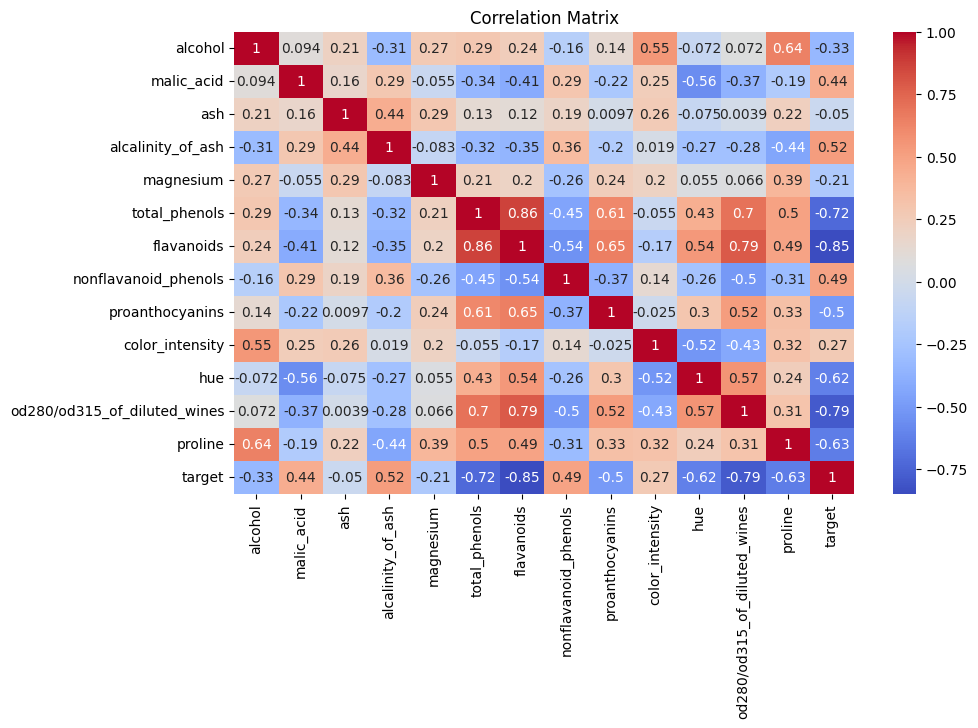

In [20]:
import seaborn as sns

# TODO

# Calculate correlation matrix
corr_matrix = df.corr()
# print('Correlation:', corr_matrix)

# Display highly correlated features
high_corr = corr_matrix.stack().sort_values(ascending = False)
high_corr = high_corr[high_corr != 1.0]
print('Highly Correlated features:', high_corr)

print()

# by graph
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap = 'coolwarm', annot=True).set_title('Correlation Matrix')
plt.show()

### TODO 3 : Standardization

In [21]:
from sklearn.preprocessing import StandardScaler

# TODO

# Separate X and y
X = df.drop('target', axis = 1)
y = df['target']

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### TODO 4 : Apply PCA

In [33]:
from sklearn.decomposition import PCA

# TODO

# Apply PCA
np.set_printoptions(suppress = True)
pca = PCA(n_components=None)
X_pca = pca.fit_transform(X_scaled)

# Display explained variance ratio
explained = pca.explained_variance_ratio_
print(explained)

print()

# Display number of principal components
print('Principal Components:', len(explained))

[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]

Principal Components: 13


### TODO 5 : Cumulative Variance

Cumulated Variances: [0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]



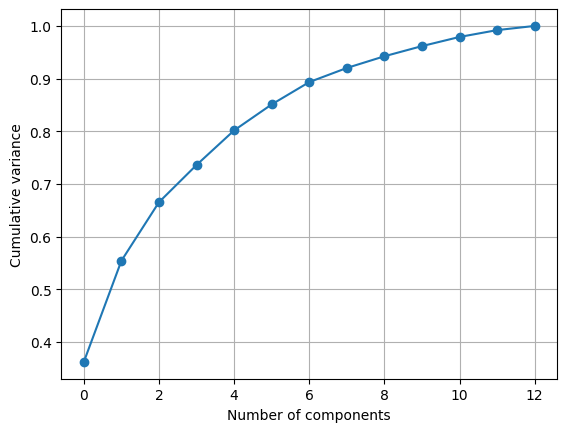

In [34]:
# TODO

# Calculate cumulative variance
cum_variance = np.cumsum(explained)
print('Cumulated Variances:', cum_variance)

# Plot cumulative variance graph
print()

plt.plot(cum_variance, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance")
plt.grid()
plt.show()

### TODO 6 : Logistic Regression WITHOUT PCA

In [40]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

# TODO using pipeline perform these tasks

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# StandardScaler
# Logistic Regression
no_pca = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter = 500))
    ]
)

no_pca.fit(X_train, y_train)
no_pca_pred = no_pca.predict(X_test)

# Calculate Accuracy
acc_no_pca = accuracy_score(y_test, no_pca_pred)
print('Accuracy:', round(acc_no_pca, 2))

Accuracy: 0.97


### TODO 7 : Logistic Regression WITH PCA

In [55]:
# TODO

# StandardScaler
# PCA(95% rakhte joto gula component lage totogulo use kore)
# Logistic Regression

with_pca = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components = 0.95)),
        ('clf', LogisticRegression(max_iter = 500))
    ]
)
with_pca.fit(X_train, y_train)
with_pca_pred = with_pca.predict(X_test)

# Calculate Accuracy
with_pca_acc = accuracy_score(y_test, with_pca_pred)
print('Accuracy (With PCA):', round(with_pca_acc, 2))

Accuracy (With PCA): 0.97


### TODO 8 : Compare Results

In [56]:
# TODO

# Create a small comparison table
# Without PCA
# With PCA
# Accuracy
# Number of Features

comparison = pd.DataFrame(
    {
        'Model': ['Without PCA', 'With PCA'],
        'Accuracy': [round(acc_no_pca, 2), round(with_pca_acc, 2)],
        'Number of Features': [X_train.shape[1], with_pca.named_steps['pca'].n_components_]
    }
)

comparison

,Model,Accuracy,Number of Features
0,Without PCA,0.97,13
1,With PCA,0.97,10


Q: In this dataset, would you recomment PCA? Justify and explain your observation


A: I would recommend PCA because it provides the same accuracy (0.97) compared to the result without PCA, while reducing the dimensionality from 13 to 10. Since accuracy didn't drop despite using fewer features, PCA gives a more efficient model without losing performance.